Valid packets: 1589  |  Rejected: 0
hxr10States: 1589  |  hxr10 flips: 10
hxr11States: 1589  |  hxr11 flips: 10


  SXR1: 79450
  SXR2: 79450
  SXR3: 79450
  SXR4: 79450
  HXR: 79450
  EUV: 79450
  hxr10States: 1589
  hxr11States: 1589
  Expected ADC length: 79450  (=1589 packets × 50 segments)


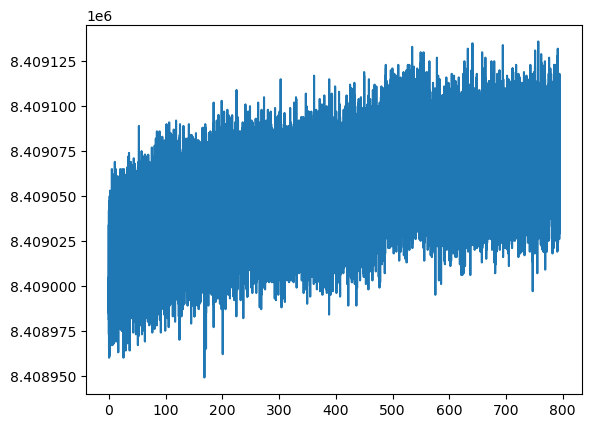

/tmp/claude-501/ipykernel_85650/1888144561.py:296: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


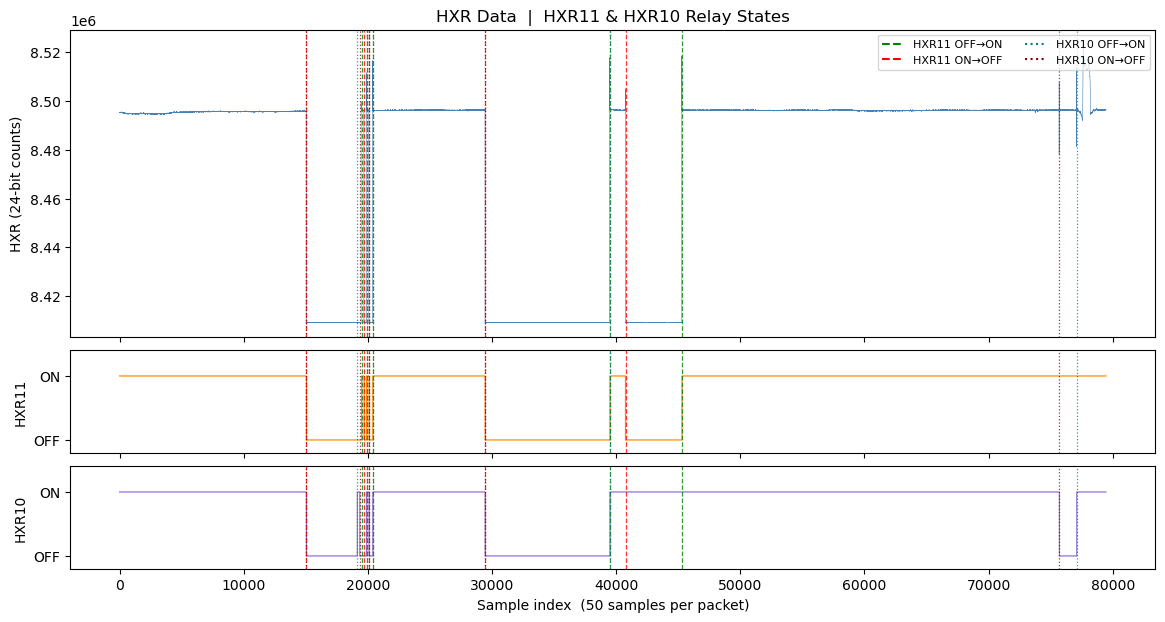

HXR11 flips (10):
  packet  301  sample ~  15050  ON->OFF
  packet  390  sample ~  19500  OFF->ON
  packet  394  sample ~  19700  ON->OFF
  packet  398  sample ~  19900  OFF->ON
  packet  402  sample ~  20100  ON->OFF
  packet  408  sample ~  20400  OFF->ON
  packet  589  sample ~  29450  ON->OFF
  packet  790  sample ~  39500  OFF->ON
  packet  815  sample ~  40750  ON->OFF
  packet  906  sample ~  45300  OFF->ON

HXR10 flips (10):
  packet  301  sample ~  15050  ON->OFF
  packet  383  sample ~  19150  OFF->ON
  packet  387  sample ~  19350  ON->OFF
  packet  398  sample ~  19900  OFF->ON
  packet  402  sample ~  20100  ON->OFF
  packet  408  sample ~  20400  OFF->ON
  packet  589  sample ~  29450  ON->OFF
  packet  790  sample ~  39500  OFF->ON
  packet 1514  sample ~  75700  ON->OFF
  packet 1542  sample ~  77100  OFF->ON


In [1]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
import matplotlib.pyplot as plt
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
import csv

# ICD §5.1: Packet Size = 950 bytes, Little Endian
# ICD Table 10 header layout (44 bytes total before ADC data):
#   [0:4]   Start ID "ASIO"
#   [4]     Relay Configuration (1 byte)
#   [5:15]  Temperature Data (10 bytes = 5 sensors × 2 bytes each, 16-bit LE)
#   [15]    Bad Command Count (1 byte)
#   [16]    Padded Zero (1 byte)
#   [17:19] Voltage data (2 bytes, 16-bit LE)
#   [19:21] Current data (2 bytes, 16-bit LE)
#   [21:23] Packet Count (2 bytes, 16-bit LE)
#   [23]    Command Count (1 byte)
#   [24:30] MUSE Time (6 bytes: 4 seconds + 2 sub-seconds, LE)
#   [30:32] Padded Zeros (2 bytes)
#   [32:36] ASIO Time ms (4 bytes, 32-bit LE)
#   [36:40] First Data Point ASIO Time ms (4 bytes, 32-bit LE)
#   [40:44] Padded Zeros (4 bytes)
#   [44:944] ADC Data (900 bytes = 50 segments x 18 bytes)
#   [944:948] End ID "STOP"
#   [948:950] CRC (2 bytes)

PACKET_SIZE = 950
HEADER_SIZE = 44
ADC_SEGMENT_BYTES = 18  # 6 channels x 3 bytes each
N_SEGMENTS = 50  # per packet
ADC_DATA_SIZE = N_SEGMENTS * ADC_SEGMENT_BYTES  # 900 bytes
STOP_OFFSET = HEADER_SIZE + ADC_DATA_SIZE  # 944

rawdata = np.fromfile(
    "/Users/evanwilliams/Desktop/ltv_experiment/20260602.0x02B4",
    dtype=np.uint8,
)


def find(targetString, data):
    targetBytes = targetString.encode()
    targetIntegers = np.frombuffer(targetBytes, dtype=np.uint8)
    windows = sliding_window_view(data, len(targetIntegers))
    matches = (windows == targetIntegers).all(axis=1)
    return np.where(matches)[0]


def decode16le(b2):
    """2 bytes -> unsigned 16-bit little-endian integer."""
    return int(b2[0]) | (int(b2[1]) << 8)


def decode24le(b3):
    """3 bytes -> unsigned 24-bit little-endian integer (ICD §5.1.3, Table 13)."""
    return int(b3[0]) | (int(b3[1]) << 8) | (int(b3[2]) << 16)


def decode32le(b4):
    """4 bytes -> unsigned 32-bit little-endian integer."""
    return int(b4[0]) | (int(b4[1]) << 8) | (int(b4[2]) << 16) | (int(b4[3]) << 24)


# ----- Build packet list using fixed offsets (ICD §5.1.2: 950-byte fixed packet) -----
# Searching for STOP at asioIndex + STOP_OFFSET is far more robust than pairing
# find("STOP") results, which breaks if "STOP" appears by coincidence inside ADC data.
asioMatches = find("ASIO", rawdata)

packetList = []
bad_packets = 0
for asioIndex in asioMatches:
    end = asioIndex + PACKET_SIZE
    if end > len(rawdata):
        bad_packets += 1
        continue
    stop_check = rawdata[
        asioIndex + STOP_OFFSET : asioIndex + STOP_OFFSET + 4
    ].tobytes()
    if stop_check != b"STOP":
        bad_packets += 1
        continue
    packetList.append(rawdata[asioIndex:end])

print(f"Valid packets: {len(packetList)}  |  Rejected: {bad_packets}")


# ----- Extract relay config, flip events, and all header housekeeping fields -----
def parseHeader(packet):
    """Return a dict of all header fields for one packet."""
    relay = int(packet[4])

    temps_raw = [decode16le(packet[5 + i * 2 : 7 + i * 2]) for i in range(5)]
    bad_cmd_count = int(packet[15])
    voltage_raw = decode16le(packet[17:19])
    current_raw = decode16le(packet[19:21])
    packet_count = decode16le(packet[21:23])
    cmd_count = int(packet[23])

    # MUSE time: 4 bytes seconds + 2 bytes sub-seconds (LE, epoch = 1958-01-01)
    muse_sec = decode32le(packet[24:28])
    muse_subsec = decode16le(packet[28:30])

    asio_time_ms = decode32le(packet[32:36])
    first_dp_asio_ms = decode32le(packet[36:40])

    return {
        "relay": relay,
        "temps_raw": temps_raw,
        "bad_cmd_count": bad_cmd_count,
        "voltage_raw": voltage_raw,
        "current_raw": current_raw,
        "packet_count": packet_count,
        "cmd_count": cmd_count,
        "muse_sec": muse_sec,
        "muse_subsec": muse_subsec,
        "asio_time_ms": asio_time_ms,
        "first_dp_ms": first_dp_asio_ms,
    }


def getRelayConfig(packetList):
    relayConfigs = []
    hxr10States = []
    hxr11States = []
    hxr10_flips = []
    hxr11_flips = []
    prevHXR10 = None
    prevHXR11 = None

    for idx, packet in enumerate(packetList):
        relayByte = int(packet[4])
        relayConfigs.append(relayByte)

        # ICD Table 12: bit layout LSB->MSB = EUV5,EUV6,EUV7,HXR8,HXR9,HXR10,HXR11,Unused
        hxr10State = bool((relayByte >> 5) & 0x01)  # bit 5
        hxr11State = bool((relayByte >> 6) & 0x01)  # bit 6
        hxr10States.append(hxr10State)
        hxr11States.append(hxr11State)

        if prevHXR10 is not None and hxr10State != prevHXR10:
            direction = "OFF->ON" if hxr10State else "ON->OFF"
            hxr10_flips.append(
                {
                    "packet": idx,
                    "relay_byte": relayByte,
                    "direction": direction,
                    "state": hxr10State,
                }
            )

        if prevHXR11 is not None and hxr11State != prevHXR11:
            direction = "OFF->ON" if hxr11State else "ON->OFF"
            hxr11_flips.append(
                {
                    "packet": idx,
                    "relay_byte": relayByte,
                    "direction": direction,
                    "state": hxr11State,
                }
            )

        prevHXR10 = hxr10State
        prevHXR11 = hxr11State

    return relayConfigs, hxr10States, hxr11States, hxr10_flips, hxr11_flips


# ----- Parse ADC data: each channel is 3 bytes decoded as a 24-bit LE integer -----
def getData(packetList):
    _, hxr10States, hxr11States, hxr10_flips, hxr11_flips = getRelayConfig(packetList)
    print(f"hxr10States: {len(hxr10States)}  |  hxr10 flips: {len(hxr10_flips)}")
    print(f"hxr11States: {len(hxr11States)}  |  hxr11 flips: {len(hxr11_flips)}")

    SXR1, SXR2, SXR3, SXR4, HXR, EUV = [], [], [], [], [], []
    headers = []

    for packet in packetList:
        headers.append(parseHeader(packet))

        adc_bytes = packet[HEADER_SIZE : HEADER_SIZE + ADC_DATA_SIZE]
        if len(adc_bytes) != ADC_DATA_SIZE:
            raise ValueError(f"Unexpected ADC data length: {len(adc_bytes)}")

        # 50 segments of 18 bytes each; each channel = 3 bytes -> 24-bit LE integer
        for seg_start in range(0, ADC_DATA_SIZE, ADC_SEGMENT_BYTES):
            seg = adc_bytes[seg_start : seg_start + ADC_SEGMENT_BYTES]
            SXR1.append(decode24le(seg[0:3]))
            SXR2.append(decode24le(seg[3:6]))
            SXR3.append(decode24le(seg[6:9]))
            SXR4.append(decode24le(seg[9:12]))
            HXR.append(decode24le(seg[12:15]))
            EUV.append(decode24le(seg[15:18]))

    return {
        "SXR1": np.array(SXR1, dtype=np.uint32),
        "SXR2": np.array(SXR2, dtype=np.uint32),
        "SXR3": np.array(SXR3, dtype=np.uint32),
        "SXR4": np.array(SXR4, dtype=np.uint32),
        "HXR": np.array(HXR, dtype=np.uint32),
        "EUV": np.array(EUV, dtype=np.uint32),
        "hxr10States": np.array(hxr10States, dtype=bool),
        "hxr11States": np.array(hxr11States, dtype=bool),
        "hxr10_flips": hxr10_flips,
        "hxr11_flips": hxr11_flips,
        "headers": headers,
    }


data = getData(packetList)

n_packets = len(packetList)
n_segments_total = n_packets * N_SEGMENTS
for key, val in data.items():
    if key not in ("hxr10_flips", "hxr11_flips", "headers"):
        print(f"  {key}: {len(val)}")
print(
    f"  Expected ADC length: {n_segments_total}  (={n_packets} packets × {N_SEGMENTS} segments)"
)
sxr1 = data["SXR1"].astype(float)
times = np.arange(0, len(sxr1) * 0.01, 0.01)
plt.plot(times, sxr1)
plt.show()
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

hxr = data["HXR"].astype(float)
hxr10States = data["hxr10States"]
hxr11States = data["hxr11States"]
hxr10_flips = data["hxr10_flips"]
hxr11_flips = data["hxr11_flips"]

# Each packet = N_SEGMENTS (50) decoded samples.
# Repeat relay state 50x so the state axes share the same x-axis as the HXR timeseries.
SAMPLES_PER_PACKET = N_SEGMENTS
hxr10_expanded = np.repeat(hxr10States, SAMPLES_PER_PACKET).astype(float)
hxr11_expanded = np.repeat(hxr11States, SAMPLES_PER_PACKET).astype(float)

# Flip positions in sample-index space
hxr10_flip_pos = [f["packet"] * SAMPLES_PER_PACKET for f in hxr10_flips]
hxr11_flip_pos = [f["packet"] * SAMPLES_PER_PACKET for f in hxr11_flips]

# --- Layout: HXR timeseries (top, tall) / HXR11 state / HXR10 state ---
fig, (ax_hxr, ax_hxr11, ax_hxr10) = plt.subplots(
    3,
    1,
    figsize=(14, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1, 1], "hspace": 0.08},
)

# --- Top: HXR timeseries ---
ax_hxr.plot(hxr, linewidth=0.4, color="steelblue")
ax_hxr.set_ylabel("HXR (24-bit counts)")
ax_hxr.set_title("HXR Data  |  HXR11 & HXR10 Relay States")

# --- Middle: HXR11 state ---
ax_hxr11.plot(hxr11_expanded, linewidth=0.9, color="darkorange", drawstyle="steps-post")
ax_hxr11.set_ylabel("HXR11")
ax_hxr11.set_yticks([0, 1])
ax_hxr11.set_yticklabels(["OFF", "ON"])
ax_hxr11.set_ylim(-0.2, 1.4)

# --- Bottom: HXR10 state ---
ax_hxr10.plot(
    hxr10_expanded, linewidth=0.9, color="mediumpurple", drawstyle="steps-post"
)
ax_hxr10.set_ylabel("HXR10")
ax_hxr10.set_yticks([0, 1])
ax_hxr10.set_yticklabels(["OFF", "ON"])
ax_hxr10.set_ylim(-0.2, 1.4)
ax_hxr10.set_xlabel("Sample index  (50 samples per packet)")

axes = [ax_hxr, ax_hxr11, ax_hxr10]

# HXR11 flip lines through all panels (green = ON, red = OFF)
for f, pos in zip(hxr11_flips, hxr11_flip_pos):
    c = "green" if f["direction"].endswith("ON") else "red"
    for ax in axes:
        ax.axvline(x=pos, color=c, linestyle="--", linewidth=0.9, alpha=0.8)

# HXR10 flip lines through all panels (teal = ON, darkred = OFF)
for f, pos in zip(hxr10_flips, hxr10_flip_pos):
    c = "teal" if f["direction"].endswith("ON") else "darkred"
    for ax in axes:
        ax.axvline(x=pos, color=c, linestyle=":", linewidth=0.9, alpha=0.8)

# Legend
legend_elements = [
    Line2D([0], [0], color="green", linestyle="--", label="HXR11 OFF→ON"),
    Line2D([0], [0], color="red", linestyle="--", label="HXR11 ON→OFF"),
    Line2D([0], [0], color="teal", linestyle=":", label="HXR10 OFF→ON"),
    Line2D([0], [0], color="darkred", linestyle=":", label="HXR10 ON→OFF"),
]
ax_hxr.legend(handles=legend_elements, loc="upper right", fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

# Summary
print(f"HXR11 flips ({len(hxr11_flips)}):")
for f in hxr11_flips:
    print(
        f"  packet {f['packet']:4d}  sample ~{f['packet']*SAMPLES_PER_PACKET:7d}  {f['direction']}"
    )
print(f"\nHXR10 flips ({len(hxr10_flips)}):")
for f in hxr10_flips:
    print(
        f"  packet {f['packet']:4d}  sample ~{f['packet']*SAMPLES_PER_PACKET:7d}  {f['direction']}"
    )

In [2]:
# 1. Pull the parsed science channels out of the data dict produced above
SXR1 = data["SXR1"]
SXR2 = data["SXR2"]
SXR3 = data["SXR3"]
SXR4 = data["SXR4"]
HXR = data["HXR"]
EUV = data["EUV"]
total_samples = len(SXR1)

time_axis = np.arange(285.0, 285.0 + total_samples * 10.0, 10.0)

# 2. Merge array vectors into a standard 7-column structured matrix configuration
export_matrix = np.column_stack((time_axis, SXR1, SXR2, SXR3, SXR4, HXR, EUV))

output_filename = "ASIO_Science_Generated.csv"

# 3. Stream data formatting precisely via unquoted 16-decimal double float strings
with open(output_filename, mode="w", newline="") as csv_file:
    writer = csv.writer(
        csv_file, delimiter=",", quoting=csv.QUOTE_NONE, escapechar=None
    )
    for row in export_matrix:
        # Formats the time array to a single decimal, science streams to precise engineering notation
        formatted_row = [
            f"{row[0]:.1f}",
            f"{row[1]:.16e}",
            f"{row[2]:.16e}",
            f"{row[3]:.16e}",
            f"{row[4]:.16e}",
            f"{row[5]:.16e}",
            f"{row[6]:.16e}",
        ]
        writer.writerow(formatted_row)

print(
    f"\n[SUCCESS] Exported raw parameter array data back directly into '{output_filename}'."
)
print("Formatting check matching index baseline requirements verified.")


[SUCCESS] Exported raw parameter array data back directly into 'ASIO_Science_Generated.csv'.
Formatting check matching index baseline requirements verified.
